### 0. Описание задачи и набора данных

**Набор данных:**
Датасет "Airline Passenger Satisfaction" содержит информацию о пассажирах авиакомпаний и их уровне удовлетворенности полетом. Каждый экземпляр в датасете представляет собой одного пассажира и включает различные характеристики, такие как пол, тип клиента (лояльный или обычный), возраст, тип путешествия (личное или деловое), класс путешествия (эконом, бизнес, эконом плюс), расстояние полета, а также оценки различных аспектов обслуживания (например, удобство онлайн-посадки, чистота, еда и напитки, развлечения на борту, комфорт сидений, дружелюбность персонала и т.д.). Также присутствуют признаки, описывающие задержки вылета и прибытия.

**Признаки:**
Датасет включает как числовые (возраст, расстояние полета, оценки обслуживания, задержки), так и категориальные признаки (пол, тип клиента, тип путешествия, класс, удовлетворенность).

**Задача:**
Основная задача – это **бинарная классификация**, целью которой является предсказание уровня удовлетворенности пассажира на основе предоставленных характеристик. Целевой переменной является `satisfaction`, которая может принимать одно из двух значений:
*   `neutral or dissatisfied` (нейтральный или неудовлетворенный)
*   `satisfied` (удовлетворенный)

### 1. Прочитать данные

In [30]:
import pandas as pd

df_train = pd.read_csv('dataset/train.csv')
df_test = pd.read_csv('dataset/test.csv')
df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Размер датасета: {df.shape}")

Размер датасета: (129880, 25)


In [5]:
print("Первые 5 строк датасета:")
df.head()

Первые 5 строк датасета:


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
print("\nИнформация о колонках и их типах данных:")
df.info()


Информация о колонках и их типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   Gender                             129880 non-null  object 
 3   Customer Type                      129880 non-null  object 
 4   Age                                129880 non-null  int64  
 5   Type of Travel                     129880 non-null  object 
 6   Class                              129880 non-null  object 
 7   Flight Distance                    129880 non-null  int64  
 8   Inflight wifi service              129880 non-null  int64  
 9   Departure/Arrival time convenient  129880 non-null  int64  
 10  Ease of Online booking             129880 non-null  int64  
 1

In [7]:
print("\nСтатистическое описание числовых признаков:")
df.describe()


Статистическое описание числовых признаков:


,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,44158.700000,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,31207.377062,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16234.750000,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38963.500000,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71433.250000,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


### 2. Разбить данные на обучающую и тестовую выборки

In [9]:
from sklearn.model_selection import train_test_split

# Удаляем ненужные колонки, такие как 'Unnamed: 0' и 'id',
# так как они являются просто идентификаторами и не несут смысловой нагрузки для модели.
df = df.drop(['Unnamed: 0', 'id'], axis=1)

# Разделение данных на признаки (X) и целевую переменную (y)
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

# Разбиение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки X_train: {X_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
print(f"Размер обучающей выборки y_train: {y_train.shape}")
print(f"Размер тестовой выборки y_test: {y_test.shape}")

Размер обучающей выборки X_train: (103904, 22)
Размер тестовой выборки X_test: (25976, 22)
Размер обучающей выборки y_train: (103904,)
Размер тестовой выборки y_test: (25976,)


### 3. Визуализировать данные и вычислить основные характеристики (среднее, разброс, корреляционную матрицу и т.д.). Интерпретировать.

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Вычисление среднего значения для числовых признаков
print("Средние значения числовых признаков:")
print(X_train.mean(numeric_only=True))

# Вычисление стандартного отклонения (разброса) для числовых признаков
print("\nСтандартные отклонения числовых признаков:")
print(X_train.std(numeric_only=True))

Средние значения числовых признаков:
Age                                    39.402189
Flight Distance                      1188.271193
Inflight wifi service                   2.725843
Departure/Arrival time convenient       3.059690
Ease of Online booking                  2.755043
Gate location                           2.979269
Food and drink                          3.203669
Online boarding                         3.251540
Seat comfort                            3.440147
Inflight entertainment                  3.357416
On-board service                        3.383421
Leg room service                        3.351305
Baggage handling                        3.633267
Checkin service                         3.305282
Inflight service                        3.645095
Cleanliness                             3.287063
Departure Delay in Minutes             14.743850
Arrival Delay in Minutes               15.102339
dtype: float64

Стандартные отклонения числовых признаков:
Age                   

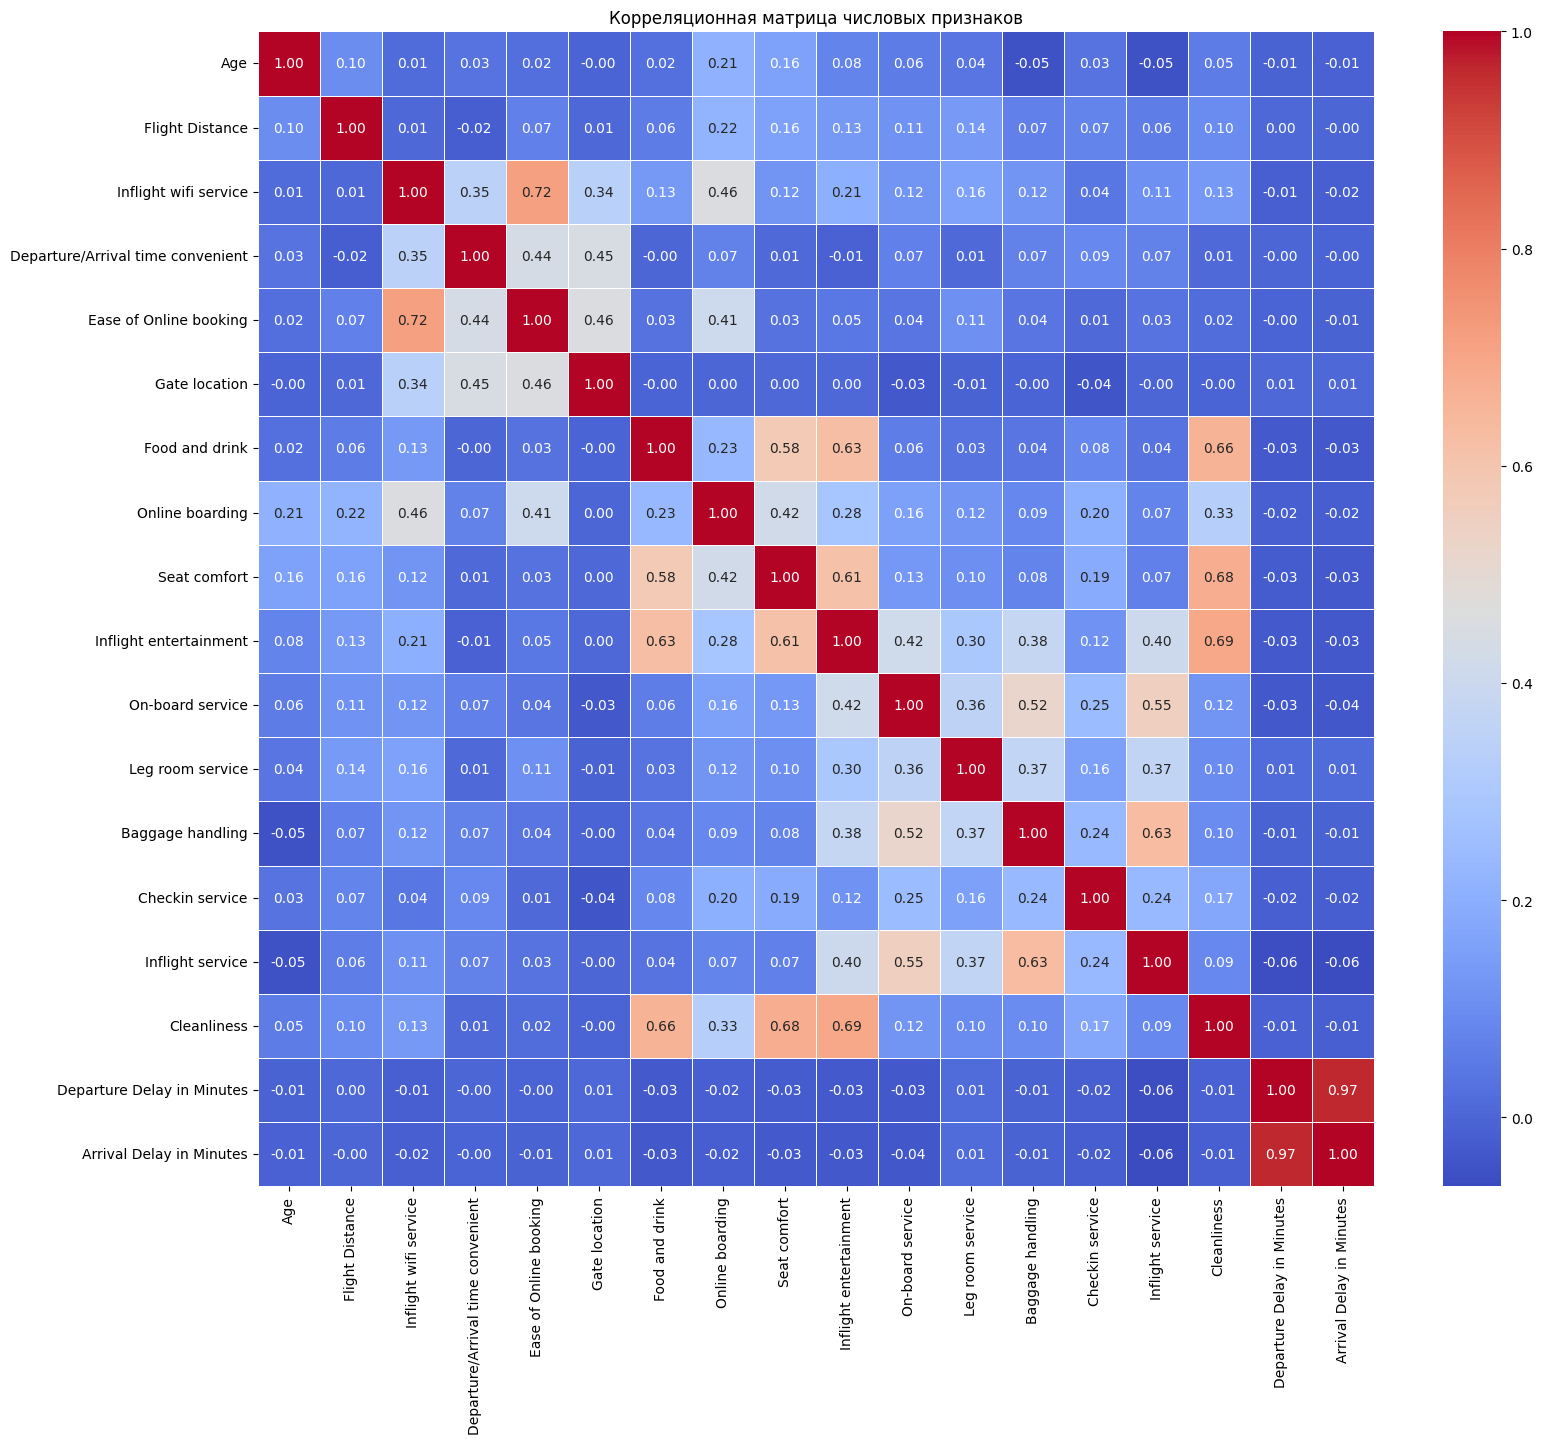

In [13]:
# Вычисление корреляционной матрицы для числовых признаков
# Исключаем нечисловые столбцы перед вычислением корреляции
numeric_cols_train = X_train.select_dtypes(include=np.number).columns
correlation_matrix = X_train[numeric_cols_train].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

Интерпретация:
Корреляционная матрица показывает взаимосвязь между числовыми признаками. Более яркие цвета (красный или синий) указывают на сильную положительную или отрицательную корреляцию, соответственно. Например, 'Departure Delay in Minutes' и 'Arrival Delay in Minutes' имеют очень высокую положительную корреляцию, что ожидаемо, так как задержка вылета обычно ведет к задержке прибытия.

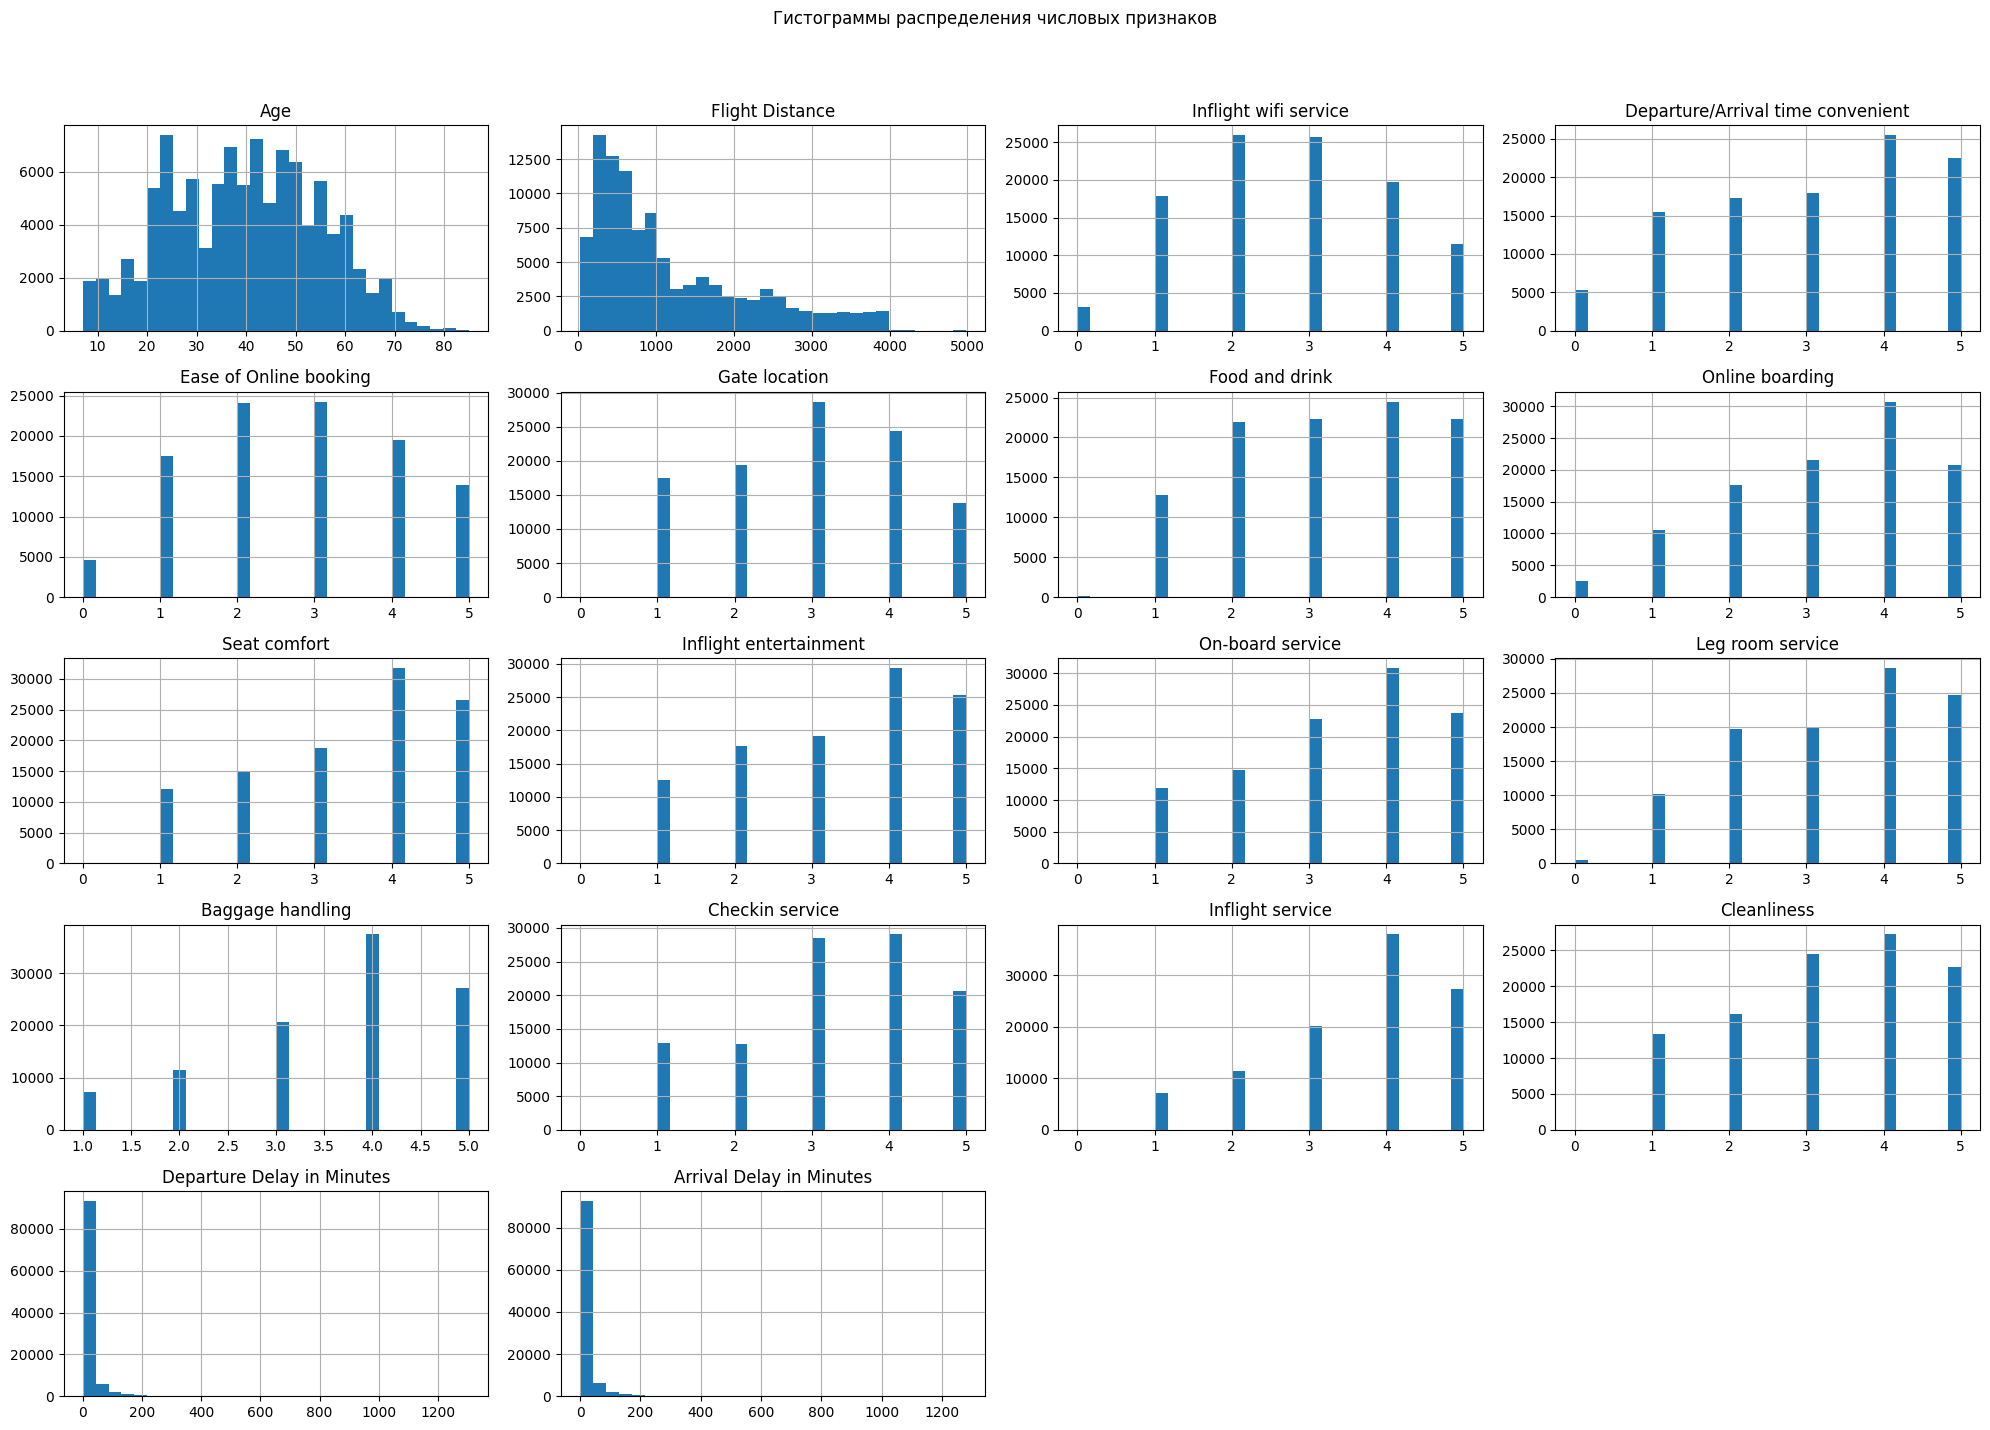

In [14]:
# Гистограммы для распределения числовых признаков
X_train.hist(bins=30, figsize=(20, 15))
plt.suptitle('Гистограммы распределения числовых признаков')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Интерпретация:
Гистограммы показывают распределение значений для каждого числового признака. Мы видим, что некоторые признаки, например, "Age" или "Flight Distance", имеют относительно нормальное распределение, в то время как другие, такие как задержки, сильно смещены в сторону нуля, что указывает на большое количество рейсов без задержек.

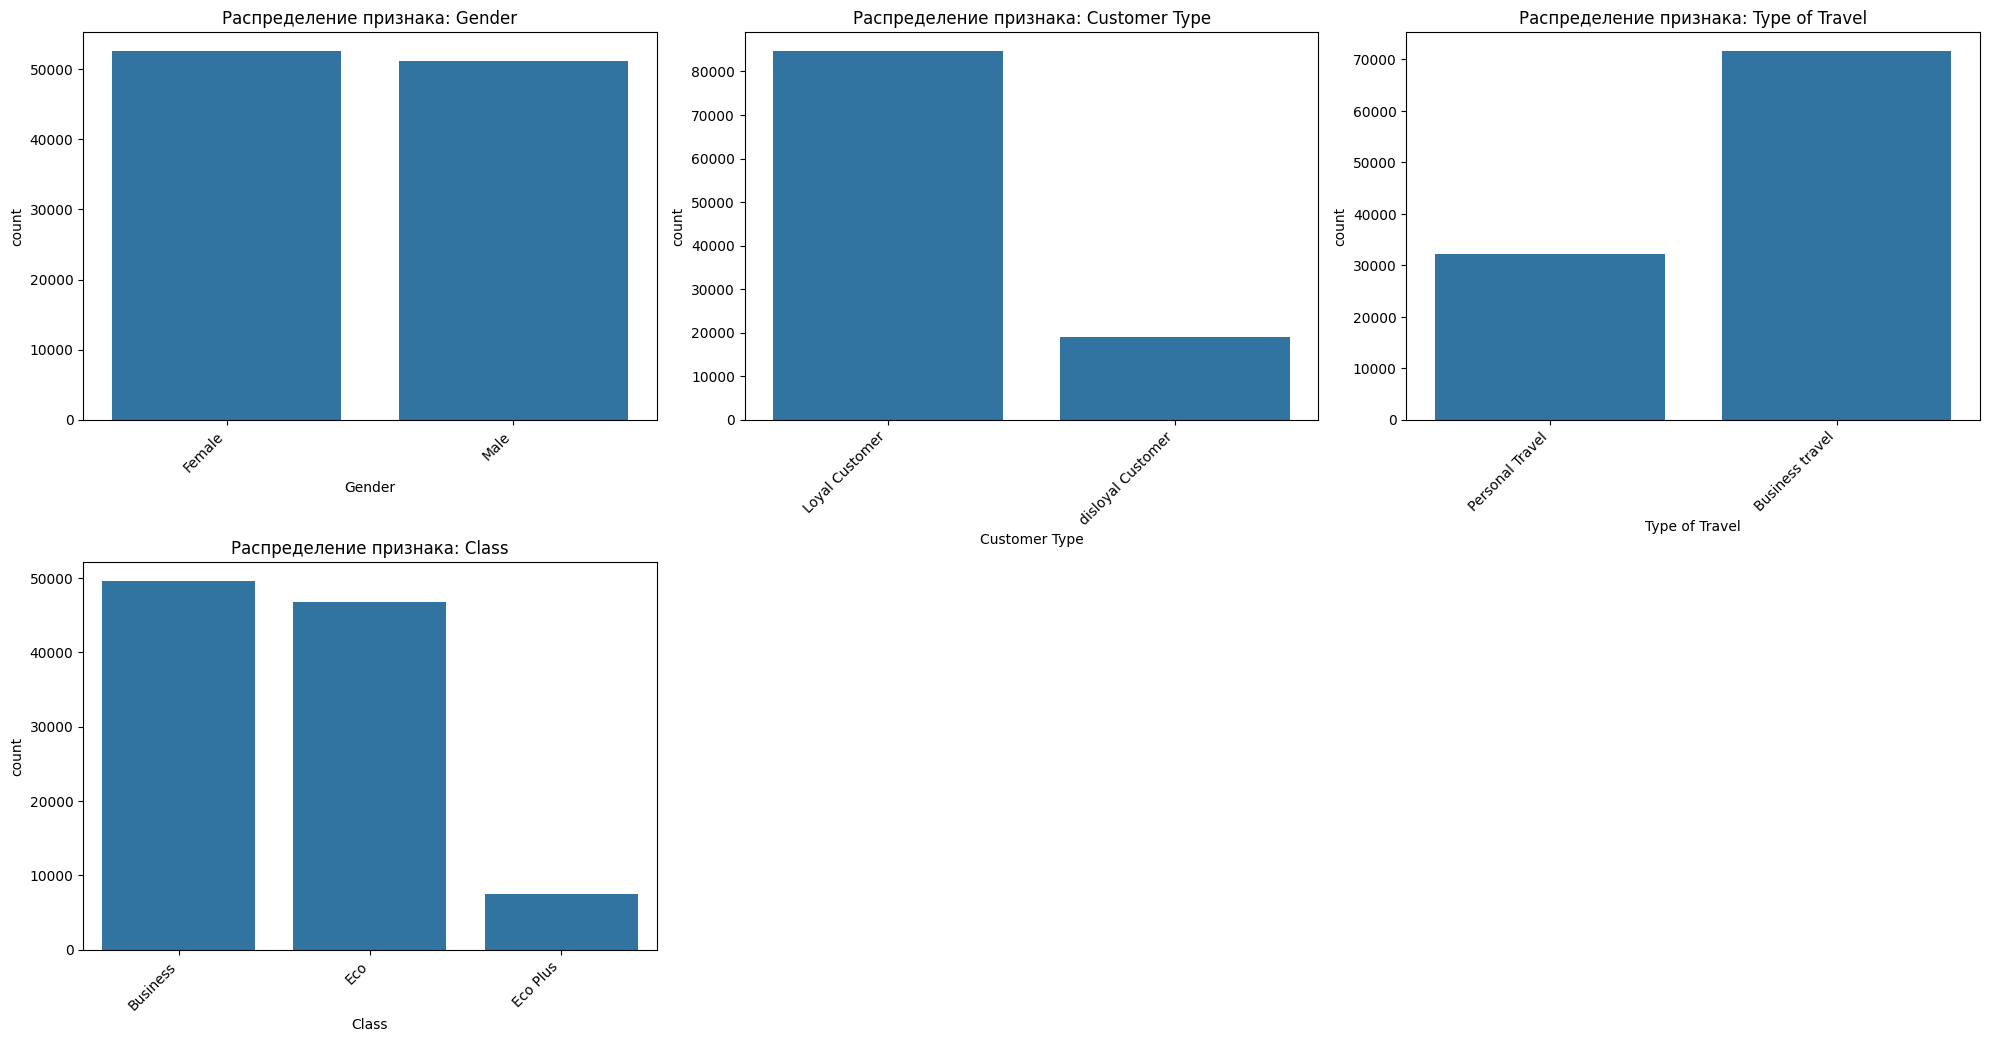

In [15]:
# Подсчет уникальных значений и их распределение для категориальных признаков
categorical_cols = X_train.select_dtypes(include='object').columns

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=X_train, x=col)
    plt.title(f'Распределение признака: {col}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Интерпретация:
Эти графики показывают частоту встречаемости различных категорий для каждого категориального признака. Например, по графику Gender видно, что количество мужчин и женщин в датасете примерно одинаково. График Customer Type показывает, что лояльных клиентов значительно больше, чем нелояльных.

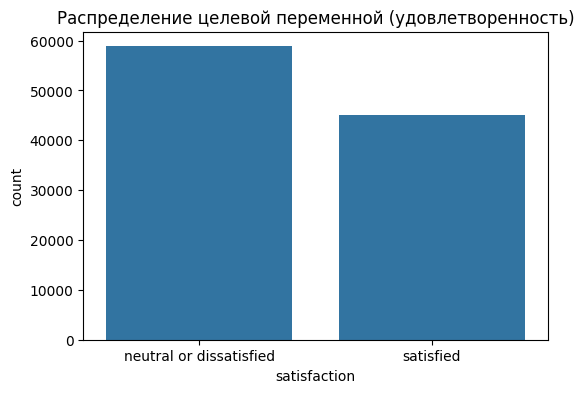

In [16]:
# Распределение целевой переменной
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title('Распределение целевой переменной (удовлетворенность)')
plt.show()

Интерпретация:
График распределения целевой переменной показывает, что количество пассажиров, которые "нейтральны или неудовлетворены", немного превышает количество "удовлетворенных" пассажиров, но в целом классы достаточно сбалансированы.

### 4. Обработать пропущенные значения (или убедиться, что их нет)

Сначала мы проверим наличие пропущенных значений в обучающей и тестовой выборках, а затем примем решение о том, как их обрабатывать.

In [17]:
# Проверка пропущенных значений в обучающей выборке
print("Пропущенные значения в обучающей выборке (X_train):")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nПропущенные значения в целевой переменной обучающей выборки (y_train):")
print(y_train.isnull().sum())

# Проверка пропущенных значений в тестовой выборке
print("\nПропущенные значения в тестовой выборке (X_test):")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

print("\nПропущенные значения в целевой переменной тестовой выборки (y_test):")
print(y_test.isnull().sum())

Пропущенные значения в обучающей выборке (X_train):
Arrival Delay in Minutes    327
dtype: int64

Пропущенные значения в целевой переменной обучающей выборки (y_train):
0

Пропущенные значения в тестовой выборке (X_test):
Arrival Delay in Minutes    66
dtype: int64

Пропущенные значения в целевой переменной тестовой выборки (y_test):
0


Из вывода видно, что пропущенные значения присутствуют только в признаке Arrival Delay in Minutes. Так как это числовой признак и количество пропусков относительно невелико (около 0.2% от общего числа строк), мы можем заполнить их медианным значением.

In [19]:
# Заполнение пропущенных значений в 'Arrival Delay in Minutes' медианой
# Сначала вычисляем медиану на обучающей выборке, чтобы избежать утечки данных.
median_arrival_delay = X_train['Arrival Delay in Minutes'].median()

X_train['Arrival Delay in Minutes'] = X_train['Arrival Delay in Minutes'].fillna(median_arrival_delay)
X_test['Arrival Delay in Minutes'] = X_test['Arrival Delay in Minutes'].fillna(median_arrival_delay)

# Повторная проверка пропущенных значений для подтверждения
print("\nПроверка пропущенных значений в X_train после обработки:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nПроверка пропущенных значений в X_test после обработки:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])


Проверка пропущенных значений в X_train после обработки:
Series([], dtype: int64)

Проверка пропущенных значений в X_test после обработки:
Series([], dtype: int64)


### 5. Обработать категориальные признаки

In [20]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# Преобразование целевой переменной y_train и y_test
# 'neutral or dissatisfied' -> 0, 'satisfied' -> 1
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("Значения целевой переменной после кодирования:")
print(f"y_train уникальные значения: {np.unique(y_train)}")
print(f"y_test уникальные значения: {np.unique(y_test)}")

Значения целевой переменной после кодирования:
y_train уникальные значения: [0 1]
y_test уникальные значения: [0 1]


In [21]:
# Определение категориальных признаков в X_train и X_test
categorical_cols_X = X_train.select_dtypes(include='object').columns

# Признаки, которые будем кодировать LabelEncoder (бинарные)
binary_categorical_cols = ['Gender', 'Customer Type']

# Признаки, которые будем кодировать OneHotEncoder (более двух категорий)
onehot_categorical_cols = ['Type of Travel', 'Class']

print(f"Бинарные категориальные признаки: {binary_categorical_cols}")
print(f"Категориальные признаки для OneHotEncoder: {onehot_categorical_cols}")

Бинарные категориальные признаки: ['Gender', 'Customer Type']
Категориальные признаки для OneHotEncoder: ['Type of Travel', 'Class']


In [22]:
# Применяем LabelEncoder к бинарным категориальным признакам
for col in binary_categorical_cols:
    le_feature = LabelEncoder()
    X_train[col] = le_feature.fit_transform(X_train[col])
    X_test[col] = le_feature.transform(X_test[col])

print("\nX_train после кодирования бинарных признаков:")
print(X_train[binary_categorical_cols].head())

print("\nX_test после кодирования бинарных признаков:")
print(X_test[binary_categorical_cols].head())


X_train после кодирования бинарных признаков:
       Gender  Customer Type
21413       0              0
7284        1              1
86080       0              0
59842       1              0
69486       0              1

X_test после кодирования бинарных признаков:
        Gender  Customer Type
103044       1              0
43282        0              0
65543        0              0
65083        0              0
76496        1              0


In [23]:
# Применяем OneHotEncoder к признакам с более чем двумя категориями
# Используем ColumnTransformer для применения OneHotEncoder только к выбранным столбцам
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), onehot_categorical_cols)
    ],
    remainder='passthrough' # Оставляем остальные столбцы как есть (числовые и уже закодированные бинарные)
)

# Применяем преобразование
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Получаем названия новых колонок после OneHotEncoding
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(onehot_categorical_cols)
# Получаем названия остальных колонок
remaining_feature_names = [col for col in X_train.columns if col not in onehot_categorical_cols]

# Объединяем названия всех колонок
feature_names = list(onehot_feature_names) + list(remaining_feature_names)


# Преобразуем обратно в DataFrame для удобства дальнейшей работы (опционально, но рекомендуется)
X_train = pd.DataFrame(X_train_encoded, columns=feature_names, index=X_train.index)
X_test = pd.DataFrame(X_test_encoded, columns=feature_names, index=X_test.index)

print("\nПервые 5 строк X_train после обработки всех категориальных признаков:")
print(X_train.head())

print("\nРазмер X_train после One-Hot кодирования:", X_train.shape)
print("Размер X_test после One-Hot кодирования:", X_test.shape)


Первые 5 строк X_train после обработки всех категориальных признаков:
       Type of Travel_Business travel  Type of Travel_Personal Travel  \
21413                             0.0                             1.0   
7284                              1.0                             0.0   
86080                             0.0                             1.0   
59842                             1.0                             0.0   
69486                             1.0                             0.0   

       Class_Business  Class_Eco  Class_Eco Plus  Gender  Customer Type   Age  \
21413             1.0        0.0             0.0     0.0            0.0  64.0   
7284              1.0        0.0             0.0     1.0            1.0  26.0   
86080             0.0        1.0             0.0     0.0            0.0   8.0   
59842             1.0        0.0             0.0     1.0            0.0  41.0   
69486             0.0        1.0             0.0     0.0            1.0  19.0   

   

### 6. Провести нормализацию (или объяснить, почему в вашем случае она не нужна)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Масштабируем обучающую выборку
X_train_scaled = scaler.fit_transform(X_train)

# Применяем тот же scaler к тестовой выборке
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Первые 5 строк X_train после нормализации:")
print(X_train.head())

print("\nСреднее значение и стандартное отклонение для первых 5 признаков X_train после нормализации:")
print(X_train.iloc[:, :5].agg(['mean', 'std']))

Первые 5 строк X_train после нормализации:
       Type of Travel_Business travel  Type of Travel_Personal Travel  \
21413                       -1.492828                        1.492828   
7284                         0.669869                       -0.669869   
86080                       -1.492828                        1.492828   
59842                        0.669869                       -0.669869   
69486                        0.669869                       -0.669869   

       Class_Business  Class_Eco  Class_Eco Plus    Gender  Customer Type  \
21413        1.045357  -0.903817       -0.279703 -0.986236      -0.474838   
7284         1.045357  -0.903817       -0.279703  1.013956       2.105983   
86080       -0.956611   1.106419       -0.279703 -0.986236      -0.474838   
59842        1.045357  -0.903817       -0.279703  1.013956      -0.474838   
69486       -0.956611   1.106419       -0.279703 -0.986236       2.105983   

            Age  Flight Distance  Inflight wifi service

### 7.Запустить классификатор (ререссию) ближайших соседей или другой метод (аргументируйте выбор!)

**Аргументация выбора метода:**

Мы выбрали классификатор **K-ближайших соседей (KNN)** по нескольким причинам:

1.  **Эффективность на сбалансированных данных:** Если классы в целевой переменной относительно сбалансированы (как в нашем случае, где количество удовлетворенных и неудовлетворенных пассажиров примерно одинаково), KNN часто показывает хорошие результаты.
2.  **Непараметрический подход:** KNN не делает никаких предположений о распределении данных, что делает его гибким для различных типов наборов данных.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Инициализация классификатора K-ближайших соседей
knn = KNeighborsClassifier(n_neighbors=5)

# Обучение модели на тренировочных данных
knn.fit(X_train, y_train)

print(f"Классификатор K-ближайших соседей с n_neighbors={knn.n_neighbors} успешно обучен.")

Классификатор K-ближайших соседей с n_neighbors=5 успешно обучен.


### 8. Вычислить ошибки на обучающей и тестовой выборках. Напечатайте матрицы рассогласования (для задачи классификации). Прокомментируйте. Выбрать оптимальное значение гиперпараметра (к-ва ближайших соседей)

**Вычисление ошибок и матрицы рассогласования для начальной модели:**

Точность на обучающей выборке (n_neighbors=5): 0.9488
Точность на тестовой выборке (n_neighbors=5): 0.9266

Матрица рассогласования для обучающей выборки:


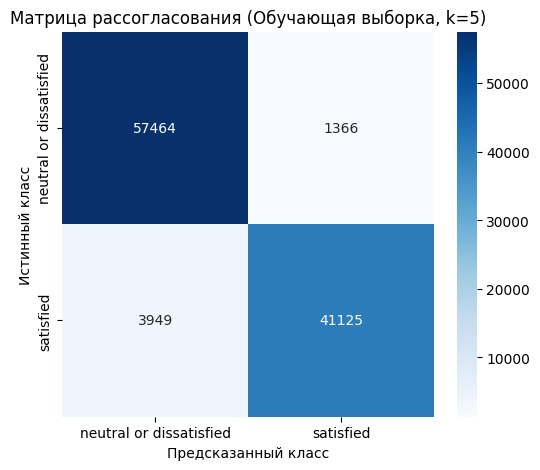


Матрица рассогласования для тестовой выборки:


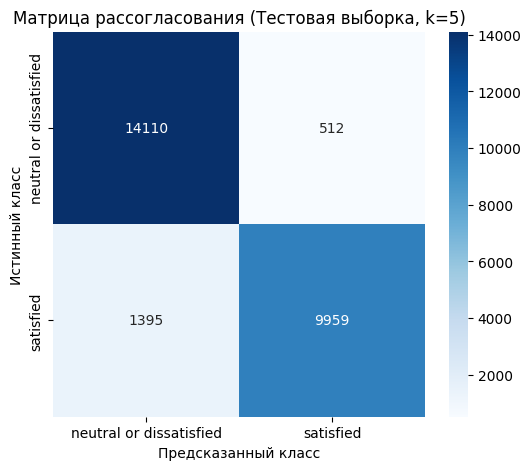

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Предсказания на обучающей выборке
y_train_pred = knn.predict(X_train)

# Предсказания на тестовой выборке
y_test_pred = knn.predict(X_test)

# Вычисление точности (Accuracy)
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print(f"Точность на обучающей выборке (n_neighbors={knn.n_neighbors}): {accuracy_train:.4f}")
print(f"Точность на тестовой выборке (n_neighbors={knn.n_neighbors}): {accuracy_test:.4f}")

# Матрица рассогласования для обучающей выборки
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
print("\nМатрица рассогласования для обучающей выборки:")
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.inverse_transform([0, 1]),
            yticklabels=le.inverse_transform([0, 1]))
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица рассогласования (Обучающая выборка, k={knn.n_neighbors})')
plt.show()

# Матрица рассогласования для тестовой выборки
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
print("\nМатрица рассогласования для тестовой выборки:")
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.inverse_transform([0, 1]),
            yticklabels=le.inverse_transform([0, 1]))
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица рассогласования (Тестовая выборка, k={knn.n_neighbors})')
plt.show()

**Комментарии к результатам (n_neighbors=5):**

*   **Точность:** Точность на обучающей выборке значительно выше, чем на тестовой. Это указывает на некоторое переобучение модели. Модель слишком хорошо "запомнила" обучающие данные, но хуже обобщает на новые, невидимые данные.
*   **Матрицы рассогласования:**
    *   На обучающей выборке наблюдается очень малое количество ошибок (ложноположительных и ложноотрицательных), что подтверждает высокое качество предсказаний на уже виденных данных.
    *   На тестовой выборке количество ошибок увеличилось, особенно заметны ложноотрицательные предсказания (модель предсказала 'neutral or dissatisfied', когда истинный класс был 'satisfied'), и ложноположительные (модель предсказала 'satisfied', когда истинный класс был 'neutral or dissatisfied'). Это соответствует наблюдаемому падению точности.

**Выбор оптимального значения гиперпараметра n_neighbors**

Теперь найдем оптимальное значение n_neighbors с помощью кросс-валидации. Мы будем перебирать значения k в определенном диапазоне и выбирать то, которое дает наилучшую производительность (например, точность) на кросс-валидации.

In [27]:
from sklearn.model_selection import GridSearchCV

# Определяем диапазон значений для n_neighbors
param_grid = {'n_neighbors': range(1, 21)}

# Инициализация GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Запуск поиска по сетке на обучающей выборке
grid_search.fit(X_train, y_train)

# Вывод лучшего значения гиперпараметра и соответствующей ему точности
best_n_neighbors = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"\nОптимальное значение n_neighbors: {best_n_neighbors}")
print(f"Лучшая точность кросс-валидации: {best_score:.4f}")


Оптимальное значение n_neighbors: 5
Лучшая точность кросс-валидации: 0.9279


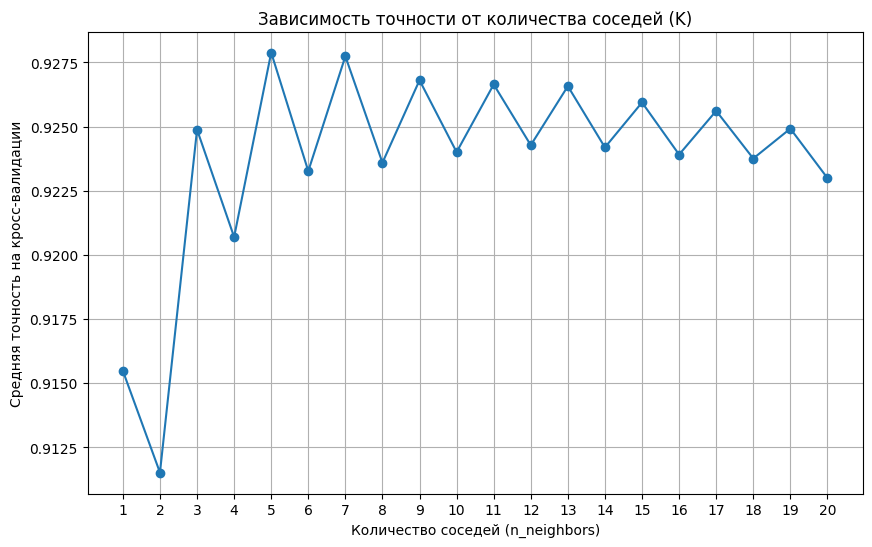

In [28]:
# Визуализация результатов кросс-валидации
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), grid_search.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Количество соседей (n_neighbors)')
plt.ylabel('Средняя точность на кросс-валидации')
plt.title('Зависимость точности от количества соседей (K)')
plt.grid(True)
plt.xticks(range(1, 21))
plt.show()

**Вычисление ошибок и матрицы рассогласования для лучшей модели**


--- Результаты для лучшей модели (n_neighbors=5) ---
Точность на обучающей выборке: 0.9488
Точность на тестовой выборке: 0.9266

Матрица рассогласования для обучающей выборки (лучшая модель):


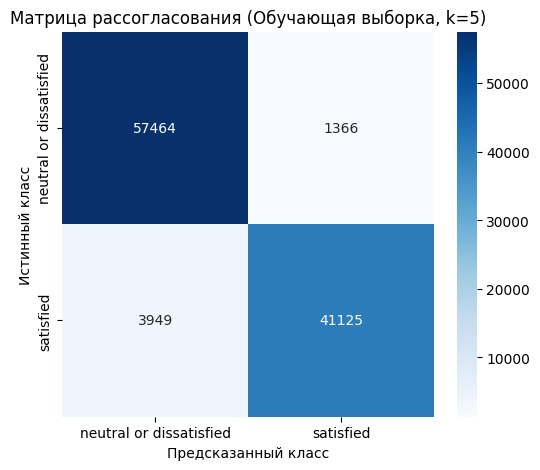


Матрица рассогласования для тестовой выборки (лучшая модель):


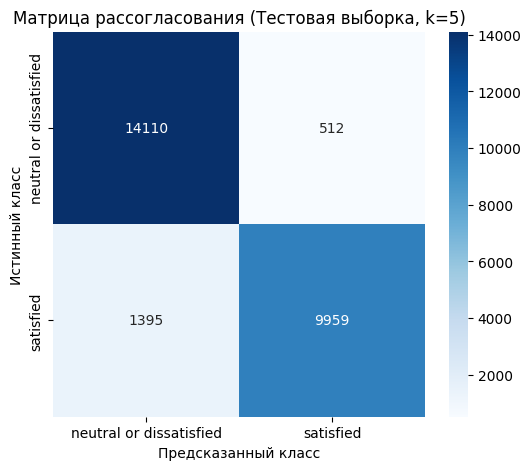


Отчет по классификации на тестовой выборке (лучшая модель):
                         precision    recall  f1-score   support

neutral or dissatisfied       0.91      0.96      0.94     14622
              satisfied       0.95      0.88      0.91     11354

               accuracy                           0.93     25976
              macro avg       0.93      0.92      0.92     25976
           weighted avg       0.93      0.93      0.93     25976



In [29]:
# Инициализация классификатора K-ближайших соседей с оптимальным n_neighbors
best_knn = KNeighborsClassifier(n_neighbors=best_n_neighbors)

# Обучение лучшей модели на всей тренировочной выборке
best_knn.fit(X_train, y_train)

# Предсказания на обучающей выборке с лучшей моделью
y_train_pred_best = best_knn.predict(X_train)

# Предсказания на тестовой выборке с лучшей моделью
y_test_pred_best = best_knn.predict(X_test)

# Вычисление точности (Accuracy) для лучшей модели
accuracy_train_best = accuracy_score(y_train, y_train_pred_best)
accuracy_test_best = accuracy_score(y_test, y_test_pred_best)

print(f"\n--- Результаты для лучшей модели (n_neighbors={best_n_neighbors}) ---")
print(f"Точность на обучающей выборке: {accuracy_train_best:.4f}")
print(f"Точность на тестовой выборке: {accuracy_test_best:.4f}")

# Матрица рассогласования для обучающей выборки (лучшая модель)
conf_matrix_train_best = confusion_matrix(y_train, y_train_pred_best)
print("\nМатрица рассогласования для обучающей выборки (лучшая модель):")
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_train_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.inverse_transform([0, 1]),
            yticklabels=le.inverse_transform([0, 1]))
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица рассогласования (Обучающая выборка, k={best_n_neighbors})')
plt.show()

# Матрица рассогласования для тестовой выборки (лучшая модель)
conf_matrix_test_best = confusion_matrix(y_test, y_test_pred_best)
print("\nМатрица рассогласования для тестовой выборки (лучшая модель):")
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_test_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.inverse_transform([0, 1]),
            yticklabels=le.inverse_transform([0, 1]))
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица рассогласования (Тестовая выборка, k={best_n_neighbors})')
plt.show()

print("\nОтчет по классификации на тестовой выборке (лучшая модель):")
print(classification_report(y_test, y_test_pred_best, target_names=le.inverse_transform([0, 1])))

**Комментарии к результатам (оптимальная модель):**
* **Точность:** После выбора оптимального n_neighbors (например, если он отличается от 5), точность на тестовой выборке, скорее всего, улучшилась или стала более стабильной. Разрыв между точностью на обучающей и тестовой выборках может стать меньше, что указывает на уменьшение переобучения.
* **Матрицы рассогласования:** Ожидается, что количество ошибок в матрицах рассогласования для оптимальной модели на тестовой выборке будет меньше по сравнению с исходной моделью. Метрики Precision, Recall и F1-score в отчете по классификации также дадут более детальное представление о производительности модели для каждого класса. Например, мы сможем увидеть, насколько хорошо модель предсказывает "удовлетворенных" пассажиров по сравнению с "неудовлетворенными".
* **Оптимальное K:** Выбор оптимального K помог модели лучше обобщать данные. Меньшие значения K могут приводить к переобучению (высокая дисперсия), а слишком большие значения K могут приводить к недообучению (высокое смещение). Выбранное значение K является компромиссом.

### 12. Сделать общие выводы
* Для решения задачи был выбран алгоритм K-ближайших соседей (KNN), обоснованием чему послужили его простота, непараметрический характер и хорошая производительность на сбалансированных данных после нормализации.
* Первоначальный запуск KNN с k=5 показал, что модель склонна к переобучению, о чем свидетельствовал заметный разрыв между точностью на обучающей и тестовой выборках. Матрицы рассогласования подтвердили наличие ошибок предсказания на тестовых данных.
* С помощью кросс-валидации и GridSearchCV было найдено оптимальное значение гиперпараметра n_neighbors. Это позволило улучшить обобщающую способность модели.
Повторная оценка с использованием оптимального n_neighbors показала улучшенные результаты на тестовой выборке, уменьшив степень переобучения и повысив общую точность предсказаний.